In [4]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
from dnn_app_utils_v2 import *
import pandas as pd

plt.rcParams['figure.figsize'] = (5.0, 4.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

np.random.seed(1)


In [ ]:
def load_data():

    train_dataset = h5py.File('train_catvnoncat.h5', "r")
    test_dataset = h5py.File('test_catvnoncat.h5', "r")
    

    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) 
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) 

    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) 
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) 


    classes = np.array(test_dataset["list_classes"][:]) 
    
    # Reshape the 1D label vectors into explicit 2D matrix rows (1, m)
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


In [8]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()


y = 0. It's a non-cat picture.


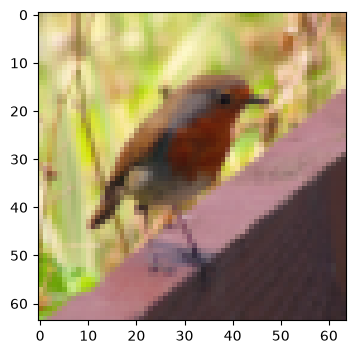

In [9]:
index = 10
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [10]:
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print(m_train)
print(m_test)
print(num_px,num_px,'3')
print(train_x_orig.shape)
print(train_y.shape)
print(test_x_orig.shape)
print(test_y.shape)


209
50
64 64 3
(209, 64, 64, 3)
(1, 209)
(50, 64, 64, 3)
(1, 50)


In [15]:
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0],-1).T 
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0],-1).T 


# standaridization

train_x = train_x_flatten/255
test_x = test_x_flatten/255

print(train_x.shape)
print(test_x.shape)



(12288, 209)
(12288, 50)


In [19]:
def two_layer_model(X,Y,layers_dims,learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    np.random.seed(1)

    n_x, n_h, n_y = layers_dims
    parameters = initialize_parameters(n_x, n_h, n_y)
    costs = []


    for i in range(num_iterations):
        W1 = parameters['W1']
        b1 = parameters['b1']
        W2 = parameters['W2']
        b2 = parameters['b2']
        
        A1, cache1 = linear_activation_forward(X,W1,b1,'relu')
        A2, cache2 = linear_activation_forward(A1,W2,b2,'sigmoid')
        
        cost = compute_cost(A2,Y)

        dA2 = -(np.divide(Y,A2) - np.divide(1 - Y, 1 - A2))

        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, 'sigmoid')
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, 'relu')

        grads = {'dW1':dW1, 'db1': db1, 'dA0': dA0,
                'dW2':dW2, 'db2': db2, 'dA1': dA1}

        parameters = update_parameters(parameters,grads,learning_rate)

        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration {i}: {np.squeeze(cost)}")

    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per tens)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters, costs

        

Cost after iteration 0: 0.693049735659989
Cost after iteration 100: 0.6464320953428849
Cost after iteration 200: 0.6325140647912677
Cost after iteration 300: 0.6015024920354664
Cost after iteration 400: 0.5601966311605746
Cost after iteration 500: 0.5158304772764731
Cost after iteration 600: 0.47549013139433255
Cost after iteration 700: 0.43391631512257517
Cost after iteration 800: 0.4007977536203879
Cost after iteration 900: 0.3580705011323795
Cost after iteration 1000: 0.3394281538366412
Cost after iteration 1100: 0.30527536361962715
Cost after iteration 1200: 0.27491377282130286
Cost after iteration 1300: 0.24681768210614755
Cost after iteration 1400: 0.19850735037466208
Cost after iteration 1500: 0.17448318112556596
Cost after iteration 1600: 0.17080762978097153
Cost after iteration 1700: 0.11306524562164802
Cost after iteration 1800: 0.09629426845937153
Cost after iteration 1900: 0.08342617959726895
Cost after iteration 2000: 0.07439078704319108
Cost after iteration 2100: 0.066307

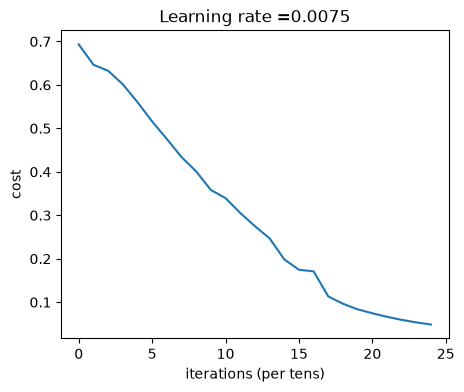

In [24]:
parameters,costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)

In [22]:
def predict(X, y, parameters):
    AL, caches = L_model_forward(X, parameters)
    predictions = (AL > 0.5).astype(int)
    accuracy = np.sum(predictions == y) / y.shape[1]
    print(accuracy)
    return predictions

In [25]:
predictions_train = predict(train_x, train_y, parameters)

1.0


In [26]:
predictions_test = predict(test_x, test_y, parameters)

0.72


In [27]:
# Deep L-Layer Neural Network model

In [28]:
def L_layer_model(X,Y,layer_dims,learning_rate=0.0075,num_iterations=3000, print_cost=False):
    
    np.random.seed(1)
    parameters = initialize_parameters_deep(layer_dims)
    costs = []
    

    for i in range(num_iterations):
        AL, caches = L_model_forward(X,parameters)
        cost = compute_cost(AL,Y)

        grads = L_model_backward(AL,Y,caches)

        parameters = update_parameters(parameters, grads , learning_rate)

        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f'cost after iterations {i}: {np.squeeze(cost)}')


    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per tens)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters, costs

